In [1]:
!pip install dowhy
import dowhy
from dowhy import CausalModel

import numpy as np
import pandas as pd
import graphviz
import networkx as nx

np.set_printoptions(precision=3, suppress=True)
np.random.seed(0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1000

experience = np.random.normal(10, 3, n_samples)

p_formation = 1 / (1 + np.exp(-(experience - 10) / 2))
formation = np.random.binomial(1, p_formation).astype(bool)

salaire = 2000 + (experience * 150) + (formation * 500) + np.random.normal(0, 200, n_samples)

subvention = np.random.binomial(1, 0.5, n_samples)

logit_formation = (experience - 10) / 2 + (subvention * 2)
p_formation_iv = 1 / (1 + np.exp(-logit_formation))
formation_iv = np.random.binomial(1, p_formation_iv).astype(bool)


salaire_iv = 2000 + (experience * 150) + (formation_iv * 500) + np.random.normal(0, 200, n_samples)

df = pd.DataFrame({
    'experience': experience,
    'subvention': subvention, # Notre INSTRUMENT
    'formation': formation_iv,
    'salaire': salaire_iv
})


In [3]:
def make_graph(adjacency_matrix, labels=None):
    idx = np.abs(adjacency_matrix) > 0.01
    dirs = np.where(idx)
    d = graphviz.Digraph(engine='dot')
    names = labels if labels else [f'x{i}' for i in range(len(adjacency_matrix))]
    for name in names:
        d.node(name)
    for to, from_, coef in zip(dirs[0], dirs[1], adjacency_matrix[idx]):
        d.edge(names[from_], names[to], label=str(coef))
    return d

def str_to_dot(string):
    '''
    Converts input string from graphviz library to valid DOT graph format.
    '''
    graph = string.strip().replace('\n', ';').replace('\t','')
    graph = graph[:9] + graph[10:-2] + graph[-1] # Removing unnecessary characters from string
    return graph

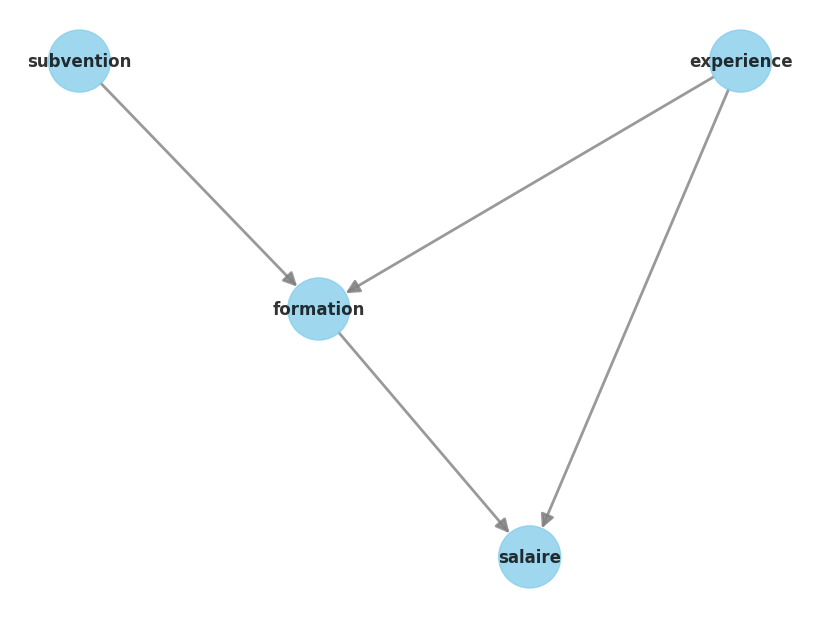

In [4]:
# I. Create a causal model from the data
model = CausalModel(
    data=df,               # Utilise ton DataFrame direct
    treatment="formation",    # Nom de la colonne en string
    outcome="salaire",        # Nom de la colonne en string
    common_causes=["experience"], 
    instruments=["subvention"] # La virgule manquante était ici
    # Note : Si tu fournis common_causes et instruments, 
    # DoWhy construit le graphe pour toi, 'graph' est optionnel.
)

model.view_model(layout="dot")


In [5]:
# II. Identify causal effect and return target estimands
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                             
────────────(E[salaire|experience])
d[formation]                       
Estimand assumption 1, Unconfoundedness: If U→{formation} and U→salaire then P(salaire|formation,experience,U) = P(salaire|formation,experience)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                   -1⎤
 ⎢      d                ⎛      d                   ⎞  ⎥
E⎢─────────────(salaire)⋅⎜─────────────([formation])⎟  ⎥
 ⎣d[subvention]          ⎝d[subvention]             ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→salaire then ¬(U →→{subvention})
Estimand assumption 2, Exclusion: If we remove {subvention}→{formation}, then ¬({subvention}→salaire)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                          

In [6]:
# III. Estimate the target estimand using a statistical method.
propensity_strat_estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.dowhy.propensity_score_stratification")

print(propensity_strat_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                             
────────────(E[salaire|experience])
d[formation]                       
Estimand assumption 1, Unconfoundedness: If U→{formation} and U→salaire then P(salaire|formation,experience,U) = P(salaire|formation,experience)

## Realized estimand
b: salaire~formation+experience
Target units: ate

## Estimate
Mean value: 525.9847633583933



In [7]:
# IV. Refute the obtained estimate using multiple robustness checks.
refute_results = model.refute_estimate(identified_estimand, propensity_strat_estimate,
                                       method_name="placebo_treatment_refuter")
print(refute_results)

Refute: Use a Placebo Treatment
Estimated effect:525.9847633583933
New effect:1.1538785914004372
p value:0.8600000000000001



Si je ne connais pas les variables instrument et communes

In [8]:
labels = [f'{col}' for i, col in enumerate(df.columns)]
data = df.to_numpy()

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.720e-05, with an active set of 4 regressors, and the smallest cholesky pivot element being 1.490e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=7.446e-06, with an active set of 5 regressors, and the smallest cholesky pivot element being 1.490e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:

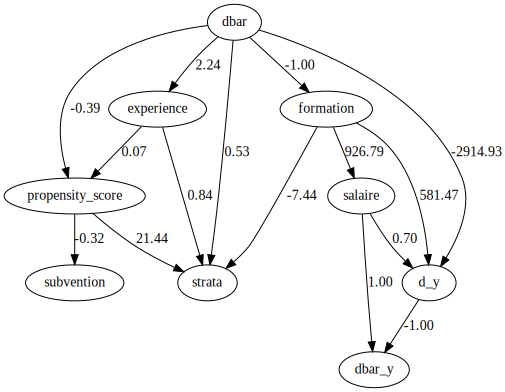

In [9]:
from causallearn.search.FCMBased import lingam
model_lingam = lingam.ICALiNGAM()
model_lingam.fit(data)

from causallearn.search.FCMBased.lingam.utils import make_dot
make_dot(model_lingam.adjacency_matrix_, labels=labels)

In [10]:
# Obtain valid dot format
graph_dot = make_graph(model_lingam.adjacency_matrix_, labels=labels)

In [11]:
# Define Causal Model
model=CausalModel(
        data = df,
        treatment='formation',
        outcome='salaire',
        graph=str_to_dot(graph_dot.source))

In [12]:
# Identification
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

# Estimation
estimate = model.estimate_effect(identified_estimand,
                                method_name="backdoor.linear_regression",
                                control_value=0,
                                treatment_value=1,
                                confidence_intervals=True,
                                test_significance=True)
print("Causal Estimate is " + str(estimate.value))

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                  
────────────(E[salaire])
d[formation]            
Estimand assumption 1, Unconfoundedness: If U→{formation} and U→salaire then P(salaire|formation,,U) = P(salaire|formation,)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                 -1⎤
 ⎢ d            ⎛ d               ⎞  ⎥
E⎢────(salaire)⋅⎜────([formation])⎟  ⎥
 ⎣d[d̅]          ⎝d[d̅]             ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→salaire then ¬(U →→{dbar})
Estimand assumption 2, Exclusion: If we remove {dbar}→{formation}, then ¬({dbar}→salaire)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                  
────────────(E[salaire])
d[formation]            
Estimand assumption 1, Unconfoundedness: If U→{formation} and U→salaire then P(salaire|formation,,